# SPARC Example 24: Single Galaxy Full Report

**EPS Research RAG Astrophysics Corpus — Unified HI Corpus v7.0**

A complete kinematic report for a single SPARC galaxy:
all metadata, rotation curve, baryonic decomposition, omega correction,
and RMSE diagnostics — from a single JSON load.

This is the kind of output a RAG system would generate
in response to: "Give me a full kinematic analysis of NGC 2403."

**Important note on corpus fidelity:** The `rotation_curve_corpus_v7_flat.csv` and `rotation_curve_corpus_v7.json` are **full-fidelity** — not a summary or veneer. The CSV contains every kinematic parameter published by Lelli et al. (2016) including per-galaxy inclination, distance uncertainties, mass-to-light ratios, and rotation curve statistics. The JSON adds full per-ring data: Vobs, Vgas, Vdisk, Vbul, errV at every radial point. This is the complete published dataset in a single machine-readable file.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19563417  
**Source:** Lelli, McGaugh & Schombert (2016), AJ 152, 157  
**Dependencies:** Python 3, numpy, matplotlib, csv (standard library only)

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

with open('rotation_curve_corpus_v7.json') as f:
    corpus = json.load(f)

GALAXY = 'NGC2403'  # Change to any SPARC galaxy
g = next(g for g in corpus['galaxies'] if g['galaxy'] == GALAXY)
d = g['data']

R     = np.array([p['Rad']   for p in d])
Vobs  = np.array([p['Vobs']  for p in d])
errV  = np.array([p['errV']  for p in d])
Vgas  = np.array([p['Vgas']  for p in d])
Vdisk = np.array([p['Vdisk'] for p in d])
Vbul  = np.array([p['Vbul']  for p in d])

Vbar = np.where(Vgas<0, -np.sqrt(Vgas**2+Vdisk**2+Vbul**2),
                         np.sqrt(Vgas**2+Vdisk**2+Vbul**2))

R1, V1 = R[0],  Vobs[0]
R2, V2 = R[-1], Vobs[-1]
omega   = (V2/R2 - V1/R1) * (R1/R2)**1.5
V_adj   = Vobs - R * omega
GM      = V2**2 * R2
V_kep   = np.sqrt(GM / R)

rmse_omega  = np.sqrt(np.mean((V_adj - Vbar)**2))
rmse_kepler = np.sqrt(np.mean((V_kep  - Vbar)**2))
outer_gap   = (V2 - R2*omega) - np.sqrt(Vgas[-1]**2+Vdisk[-1]**2+Vbul[-1]**2)

print(f"=== {GALAXY} — EPS Research Full Kinematic Report ===")
print(f"Survey:        {g['survey']} Tier {g['quality_tier']}")
print(f"Distance:      {g['distance_mpc']} ± {g.get('e_distance_mpc','?')} Mpc")
print(f"Inclination:   {g['inc_deg']} ± {g.get('e_inc_deg','?')} deg")
print(f"N rings:       {g['n_points']}")
print(f"R range:       {R.min():.2f} -- {R.max():.2f} kpc")
print(f"Vmax:          {Vobs.max():.1f} km/s")
print(f"Omega:         {omega:.3f} rad/Gyr")
print(f"RMSE omega:    {rmse_omega:.2f} km/s")
print(f"RMSE Kepler:   {rmse_kepler:.2f} km/s")
print(f"Outer gap:     {outer_gap:.2f} km/s ({'negative ✓' if outer_gap<0 else 'positive'})")

=== NGC2403 — EPS Research Full Kinematic Report ===
Survey:        SPARC Tier 1
Distance:      3.16 ± 0.16 Mpc
Inclination:   63.0 ± 3.0 deg
N rings:       73.0
R range:       0.16 -- 20.87 kpc
Vmax:          136.0 km/s
Omega:         -0.098 rad/Gyr
RMSE omega:    38.80 km/s
RMSE Kepler:   385.38 km/s
Outer gap:     75.20 km/s (positive)


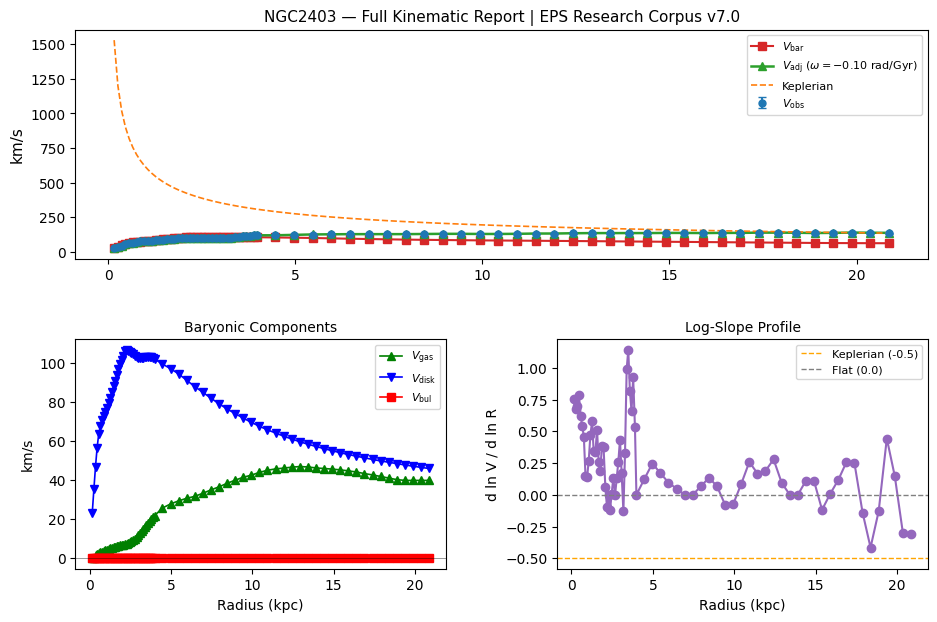

In [2]:
fig = plt.figure(figsize=(11, 7))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

ax1.errorbar(R, Vobs, yerr=errV, fmt='o', color='#1f77b4', capsize=3,
             markersize=5, label=r'$V_{\rm obs}$', zorder=5)
ax1.plot(R, Vbar,  's-', color='#d62728', lw=1.5, label=r'$V_{\rm bar}$')
ax1.plot(R, V_adj, '^-', color='#2ca02c', lw=1.8,
         label=fr'$V_{{\rm adj}}$ ($\omega={omega:.2f}$ rad/Gyr)')
ax1.plot(R, V_kep, '--', color='#ff7f0e', lw=1.2, label='Keplerian')
ax1.set_ylabel('km/s', fontsize=11)
ax1.set_title(f'{GALAXY} — Full Kinematic Report | EPS Research Corpus v7.0', fontsize=11)
ax1.legend(fontsize=8)

ax2.plot(R, Vgas,  'g^-', lw=1.2, label=r'$V_{\rm gas}$')
ax2.plot(R, Vdisk, 'bv-', lw=1.2, label=r'$V_{\rm disk}$')
ax2.plot(R, Vbul,  'rs-', lw=1.2, label=r'$V_{\rm bul}$')
ax2.axhline(0, color='k', lw=0.7, alpha=0.4)
ax2.set_xlabel('Radius (kpc)', fontsize=10)
ax2.set_ylabel('km/s', fontsize=10)
ax2.set_title('Baryonic Components', fontsize=10)
ax2.legend(fontsize=8)

lnR = np.log(R)
lnV = np.log(Vobs)
slope = np.gradient(lnV, lnR)
ax3.plot(R, slope, 'o-', color='#9467bd', lw=1.5)
ax3.axhline(-0.5, color='orange', ls='--', lw=1, label='Keplerian (-0.5)')
ax3.axhline(0.0,  color='gray',   ls='--', lw=1, label='Flat (0.0)')
ax3.set_xlabel('Radius (kpc)', fontsize=10)
ax3.set_ylabel('d ln V / d ln R', fontsize=10)
ax3.set_title('Log-Slope Profile', fontsize=10)
ax3.legend(fontsize=8)

plt.savefig(f'ex24_{GALAXY}_report.png', dpi=150, bbox_inches='tight')
plt.show()